# Carga de librerías y archivos

In [3]:
from pathlib import Path
from math import comb, exp, factorial
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

In [4]:
#Lista de archivos requeridos

ARCHIVOS_REQUERIDOS = [
    'conectividad_aerea_cabotaje.csv',
    'conectividad_aerea_internacional.csv',
    '202512-informe-ministerio-actualizado-dic-final.csv',
    '202604-informe-ministerio.csv',
    'failbondi-2026-05-20-dump.json',
]

#Búsqueda automática de los datasets
def resolver_data_dir():
    #Lista de carpetas candidatas
    candidatos = [
        Path.cwd() / 'datasets',
        Path.cwd(),
        Path.cwd().parent / 'datasets', 
        Path.cwd() / '4' / 'datasets',
        Path('/content') / 'datasets',
        Path('/content'),
        Path('/content/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica IV/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica_IV/4') / 'datasets',
    ]

    for data_dir in candidatos:
        if data_dir.exists() and all((data_dir / archivo).exists() for archivo in ARCHIVOS_REQUERIDOS):
            return data_dir

    raise FileNotFoundError(
        'No se encontraron todos los datasets.'
    )

#Ruta a los dataset
DATA_DIR = resolver_data_dir()

#Ruta a la carpeta principal del proyecto
BASE_DIR = DATA_DIR.parent if DATA_DIR.name == 'datasets' else DATA_DIR

#Obtener los nombres de los archivos
archivos = sorted(p.name for p in DATA_DIR.iterdir())
print('Carpeta de datasets:', DATA_DIR)
print('Datasets encontrados:')
for nombre in archivos:
    print('-', nombre)


Carpeta de datasets: /home/charita/Documentos/UNRN/MATE4/MateIV_Transporte_Publico/datasets
Datasets encontrados:
- 202512-informe-ministerio-actualizado-dic-final.csv
- 202604-informe-ministerio.csv
- conectividad_aerea_cabotaje.csv
- conectividad_aerea_internacional.csv
- failbondi-2026-05-20-dump.json


# Carga e inspección de datasets

Contexto del Proyecto: La Secretaría de Turismo y la Dirección de Tránsito y Transporte de la Municipalidad de San Carlos de Bariloche han solicitado un informe técnico basado en datos reales de operaciones aeroportuarias. Debido al crecimiento sostenido del turismo, la infraestructura de la ciudad y el aeropuerto se ven exigidos, especialmente en las temporadas de invierno y verano.
Objetivo: La Municipalidad necesita entender la dinámica de los arribos y partidas para:

    - Optimizar el transporte público y traslados: Ajustar las frecuencias de colectivos y servicios de traslados según el volumen de pasajeros por hora.
    - Prever la saturación de la terminal: Identificar momentos críticos donde la cantidad de vuelos supere la capacidad operativa.
    - Planificación estratégica: Utilizar modelos estadísticos para predecir flujos futuros basados en tendencias históricas.

In [5]:
DIAS = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

#Usamos on_bad_lines para que panda saltee las filas que tienen errores.
# y warn es para que nos informe cuales salteo.
def leer_anac(nombre_archivo):
    df = pd.read_csv(DATA_DIR / nombre_archivo, sep=';', decimal=',', on_bad_lines='warn')
    df.columns = df.columns.str.strip()

    for columna in ['Pasajeros', 'PAX']:
        df[columna] = pd.to_numeric(df[columna], errors='coerce')

    df['Fecha UTC'] = pd.to_datetime(
        df['Fecha UTC'],
        dayfirst=True,
        errors='coerce'
    )

    df['anio'] = df['Fecha UTC'].dt.year
    df['mes'] = df['Fecha UTC'].dt.month

    df['dia_semana'] = (
        df['Fecha UTC']
        .dt.day_name()
        .map(DIAS)
    )

    return df

anac_2025 = leer_anac('202512-informe-ministerio-actualizado-dic-final.csv')
anac_2026 = leer_anac('202604-informe-ministerio.csv')
anac = pd.concat([anac_2025, anac_2026], ignore_index=True)

print('Filas ANAC 2025:', len(anac_2025))
print('Filas ANAC 2026:', len(anac_2026))
print('Filas ANAC totales:', len(anac))



Filas ANAC 2025: 597784
Filas ANAC 2026: 197320
Filas ANAC totales: 795104


In [6]:
#INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC


print('-' * 100)
print("CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
#Cantidad de filas del dataset
print('Filas cabotaje:', len(anac))
print('Filas internacional:', len(anac))
print('Filas totales:', len(anac))

#Conocer el rango temporal del dataset

fecha_inicio = anac['Fecha UTC'].min()
fecha_fin = anac['Fecha UTC'].max()

print()
print('-' * 100)
print("RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)

print()
print("Fecha de inicio del dataset:", fecha_inicio.strftime('%d/%m/%Y'))
print("Fecha fin del dataset:", fecha_fin.strftime('%d/%m/%Y'))


print()
print('-' * 100)
print("INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
#Obtener información del dataset
anac.info()

----------------------------------------------------------------------------------------------------
CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Filas cabotaje: 795104
Filas internacional: 795104
Filas totales: 795104

----------------------------------------------------------------------------------------------------
RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Fecha de inicio del dataset: 01/01/2025
Fecha fin del dataset: 30/04/2026

----------------------------------------------------------------------------------------------------
INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795104 entries, 0 to 795103
Data columns (

In [7]:
display(anac.head())

,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aerolinea Nombre,Aeronave,Pasajeros,PAX,Calidad dato,anio,mes,dia_semana
0,2025-01-01,0:00,Regular,Doméstico,Aterrizaje,BAR,EZE,FB LÍNEAS AÉREAS - FLYBONDI,BO-737-8Q8,167.0,83.5,DEFINITIVO,2025,1,Miércoles
1,2025-01-01,0:03,Regular,Internacional,Despegue,EZE,KATL,DELTA AIRLINES,0,281.0,281.0,DEFINITIVO,2025,1,Miércoles
2,2025-01-01,0:06,Regular,Doméstico,Aterrizaje,SAL,NEU,JETSMART AIRLINES S.A.,AIB-A320-232,174.0,87.0,DEFINITIVO,2025,1,Miércoles
3,2025-01-01,0:07,Regular,Doméstico,Aterrizaje,CBA,BAR,FB LÍNEAS AÉREAS - FLYBONDI,BO-737-8U3,83.0,41.5,DEFINITIVO,2025,1,Miércoles
4,2025-01-01,0:07,Regular,Internacional,Despegue,AER,SCEL,LATAM AIRLINES GROUP S.A.(exLAN AIRLINE),0,162.0,162.0,DEFINITIVO,2025,1,Miércoles


Exploramos la cantidad de pasajeros que aterrizaron en los diferentes aeropuertos durante el periodo del dataset

In [8]:
pax_por_aeropuerto = (
    anac[anac['Tipo de Movimiento'] == 'Aterrizaje']
        .groupby('Aeropuerto', as_index=False)['PAX']
        .sum()
        .sort_values('PAX', ascending=False)
)

print(pax_por_aeropuerto)

   Aeropuerto        PAX
0         AER  7731329.5
15        EZE  7145134.0
4         CBA  1501703.0
11        DOZ  1082298.0
1         BAR   863201.5
22        IGU   607381.0
37        SAL   570277.5
29        NEU   451935.5
48        USU   404842.0
13        ECA   326936.0
46        TUC   318496.5
34        ROS   259582.0
7         CRV   186534.0
24        JUJ   162551.0
5         CHP   115238.0
33        POS   109684.0
26        MDP   103649.5
44        TRE    95633.5
2         BCA    78793.0
39        SIS    78636.5
38        SDE    72440.0
6         CRR    70582.0
23        JUA    68508.5
12        DRY    57877.5
18        GAL    45229.0
21        GRA    37463.5
42        SVO    31982.5
3         CAT    31959.0
14        ESQ    30752.5
17        FSA    29061.5
25        LAR    23868.5
47        UIS    20503.0
40        SRA    16483.0
32        PAR    14184.5
30        OSA    13944.0
49        VIE    11754.0
16        FDO    11663.5
45        TRH     5999.5
43        TRC     5434.0


# Limpieza y preparación de datos


In [9]:
#El dataset 202512-informe-ministerio-actualizado-dic-final.csv' tiene errores en sus filas
#Función para determinar en cuantas filas tiene errores.

archivo = DATA_DIR / '202512-informe-ministerio-actualizado-dic-final.csv'

# Total de filas en el archivo
with open(archivo, encoding='utf-8') as f:
    total_lineas = sum(1 for _ in f)

# Filas válidas (las que Pandas intenta leer)
df = pd.read_csv(
    archivo,
    sep=';',
    decimal=',',
    engine='python',
    on_bad_lines='skip'   # saltea las filas con errores.
)

filas_validas = len(df)
filas_ignoradas = total_lineas - filas_validas

print("Total de líneas:", total_lineas)
print("Filas cargadas:", filas_validas)
print("Filas ignoradas:", filas_ignoradas)

Total de líneas: 597785
Filas cargadas: 597784
Filas ignoradas: 1


In [10]:
resumen_datasets = pd.DataFrame({
    'dataset': ['ANAC'],
    'filas': [len(anac)],
    'columnas': [anac.shape[1]],
})
display(resumen_datasets)



print('Nulos principales en ANAC:')
display(anac[['Fecha UTC', 'Clasificación Vuelo', 'Tipo de Movimiento', 'Pasajeros', 'PAX']].isna().sum())
print()



,dataset,filas,columnas
0,ANAC,795104,15


Nulos principales en ANAC:


Fecha UTC              0
Clasificación Vuelo    0
Tipo de Movimiento     0
Pasajeros              0
PAX                    0
dtype: int64

# Análisis estadístico descriptivo


Medidas de Tendencia Central: Media y mediana de pasajeros diarios en el Aeropuerto de Bariloche.

In [14]:
# 1. Filtrar los datos para el Aeropuerto de Bariloche 
df_bariloche = anac[anac['Aeropuerto'] == 'BAR']

# 2. Agrupar por fecha para obtener el total de pasajeros diarios
pasajeros_diarios = df_bariloche.groupby('Fecha UTC')['PAX'].sum()

# 3. Cálculo de Medidas de Tendencia Central
media_pasajeros = pasajeros_diarios.mean()
mediana_pasajeros = pasajeros_diarios.median()

# 4. Mostrar resultados 
print(f"--- Informe para la Municipalidad de Bariloche ---")
print(f"Media de pasajeros diarios: {media_pasajeros:.2f}")
print(f"Mediana de pasajeros diarios: {mediana_pasajeros:.2f}")

--- Informe para la Municipalidad de Bariloche ---
Media de pasajeros diarios: 3592.04
Mediana de pasajeros diarios: 3490.00


Media: Es el promedio aritmético de pasajeros por día. Si la afluencia fuera constante durante todo el año, la Municipalidad debería esperar un movimiento de cerca de 3600 pasajeros por día en el aeropuerto.

Mediana: Es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan menos de 3490 personas y el otro 50% llegan más.

In [15]:
# Cálculo del Desvío Estándar (Requisito de Dispersión del TP)
desvio_estandar = pasajeros_diarios.std()

# Cálculo de la Varianza (Opcional, complementa el análisis)
varianza_pasajeros = pasajeros_diarios.var()

print(f"--- Análisis de Dispersión para Bariloche ---")
print(f"Desvío Estándar: {desvio_estandar:.2f}")
print(f"Varianza: {varianza_pasajeros:.2f}")

--- Análisis de Dispersión para Bariloche ---
Desvío Estándar: 1205.65
Varianza: 1453588.93


    hora      PAX
0      0  37298.0
1      1  51032.5
2      2  49438.0
3      3  56485.0
4      4  32267.5
5      5  14301.0
6      6   6509.0
7      7   4173.5
8      8   3023.5
9      9   1580.5
10    10   1349.0
11    11  16918.5
12    12  27289.5
13    13  50821.5
14    14  52615.0
15    15  53870.5
16    16  49607.5
17    17  39408.0
18    18  35633.5
19    19  38055.5
20    20  41217.5
21    21  48068.0
22    22  40943.0
23    23  39346.0
Mayor demanda: 3:00 hs - 56,485 PAX
Menor demanda: 10:00 hs - 1,349 PAX


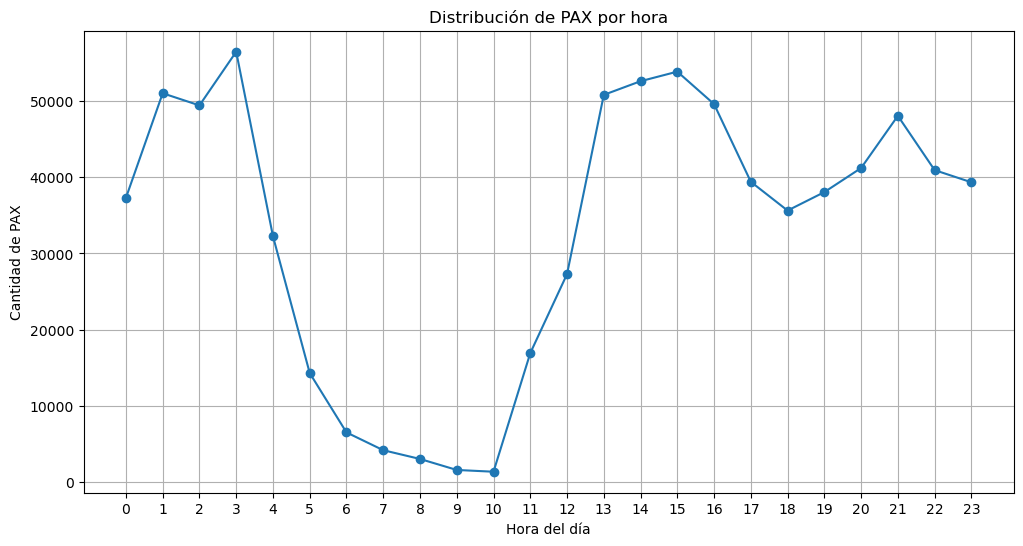

In [12]:
#Cuál es el rango horario con más pasajeros y con menos?

# Crear columna hora
anac['hora'] = pd.to_datetime(
    anac['Hora UTC'],
    format='%H:%M'
).dt.hour

# Filtrar aterrizajes en BRC
filtro = (
    (anac['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac['Origen / Destino'] == 'BAR')
)

# PAX por hora
pax_por_hora = (
    anac.loc[filtro]
        .groupby('hora', as_index=False)['PAX']
        .sum()
)

print(pax_por_hora)

# Hora de mayor y menor demanda
hora_max = pax_por_hora.loc[pax_por_hora['PAX'].idxmax()]
hora_min = pax_por_hora.loc[pax_por_hora['PAX'].idxmin()]

print(f"Mayor demanda: {int(hora_max['hora'])}:00 hs - {hora_max['PAX']:,.0f} PAX")
print(f"Menor demanda: {int(hora_min['hora'])}:00 hs - {hora_min['PAX']:,.0f} PAX")

# Gráfico
plt.figure(figsize=(12,6))
plt.plot(
    pax_por_hora['hora'],
    pax_por_hora['PAX'],
    marker='o'
)

plt.xticks(range(24))
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de PAX')
plt.title('Distribución de PAX por hora')
plt.grid(True)
plt.show()

In [ ]:
orden_dias = [
    'Lunes', 'Martes', 'Miércoles',
    'Jueves', 'Viernes', 'Sábado', 'Domingo'
]

filtro = (
    (anac['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac['Origen / Destino'] == 'BAR')
)

pax_por_dia = (
    anac.loc[filtro]
        .groupby('dia_semana')['PAX']
        .sum()
        .reindex(orden_dias)
        .reset_index()
)

print(pax_por_dia)

# Día de mayor y menor demanda
dia_max = pax_por_dia.loc[pax_por_dia['PAX'].idxmax()]
dia_min = pax_por_dia.loc[pax_por_dia['PAX'].idxmin()]

print(f"\nMayor demanda: {dia_max['dia_semana']} - {dia_max['PAX']:,.0f} PAX")
print(f"Menor demanda: {dia_min['dia_semana']} - {dia_min['PAX']:,.0f} PAX")

# Gráfico
plt.figure(figsize=(10,5))
plt.bar(pax_por_dia['dia_semana'], pax_por_dia['PAX'])

plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de PAX')
plt.title('Distribución de PAX por día de la semana')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
# Filtrar año y operación
anac_2025 = anac[
    (anac['anio'] == 2025) &
    (anac['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac['Origen / Destino'] == 'BAR')
]

# PAX por mes
pax_por_mes = (
    anac_2025.groupby('mes', as_index=False)['PAX']
        .sum()
        .sort_values('mes')
)

print(pax_por_mes)

# Mes de mayor y menor demanda
mes_max = pax_por_mes.loc[pax_por_mes['PAX'].idxmax()]
mes_min = pax_por_mes.loc[pax_por_mes['PAX'].idxmin()]

print(f"Mayor demanda: mes {int(mes_max['mes'])} - {mes_max['PAX']:,.0f} PAX")
print(f"Menor demanda: mes {int(mes_min['mes'])} - {mes_min['PAX']:,.0f} PAX")